<!-- reader-content -->

# Chip transformations

Can a smaller model reproduce the same pulse experiment? Drive the end of a
four-transmon chain, keep its nearest neighbour, and compare the resulting
active patch with the full chip. Frequencies are in GHz and times in ns.

## Declare the chain

The neighbouring transmons are separated by 350 MHz and coupled at 12 MHz.
The full model has 81 basis states.

In [1]:
import numpy as np
from quchip import RWA, Capacitive, ChargeDrive, Chip, DuffingTransmon, Gaussian, QuantumSequence

frequencies = (5.00, 5.35, 5.70, 6.05)
coupling_strength = 0.012
qubits = [
    DuffingTransmon(freq=freq, anharmonicity=-0.25, levels=3, label=f"q{index}")
    for index, freq in enumerate(frequencies)
]
couplings = [
    Capacitive(qubits[index], qubits[index + 1], g=coupling_strength, label=f"c{index}{index + 1}")
    for index in range(3)
]
chip = Chip(qubits, couplings=couplings, frame="rotating", approximation=RWA())

## Schedule a pulse and keep its neighbourhood

Drive `q0` with a 60 ns Gaussian. `active_patch(hops=1)` retains `q0` and `q1`,
folds away `q3` then `q2`, and binds the existing schedule to the reduced chip.
The source chip and sequence remain unchanged.

In [2]:
drive = ChargeDrive(qubits[0], label="q0-charge")
_ = chip.wire(drive)
sequence = QuantumSequence(chip)
_ = sequence.schedule(
    drive, envelope=Gaussian(duration=60.0, sigmas=3.0, amplitude=0.04 / 3),
    freq=chip.freq(qubits[0]),
)
patch = sequence.active_patch(hops=1, method="sw")

<details>
<summary>Plot the full chain and active patch</summary>

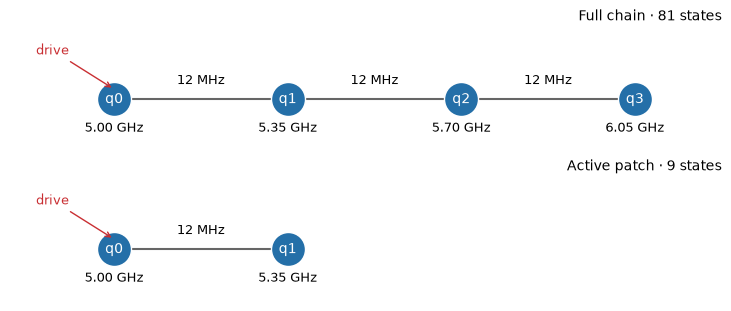

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "svg.fonttype": "none", "pdf.fonttype": 42})
topology_figure, topology_axes = plt.subplots(2, 1, figsize=(7.2, 3.0), layout="constrained")
for axis, model, title in zip(
    topology_axes, (chip, patch.chip), ("Full chain · 81 states", "Active patch · 9 states"),
):
    positions = {device.label: index for index, device in enumerate(chip.devices)}
    for coupling in model.couplings:
        x0 = positions[coupling.device_a.label]
        x1 = positions[coupling.device_b.label]
        axis.plot([x0, x1], [0, 0], color="0.4", lw=1.5, zorder=1)
        axis.text((x0 + x1) / 2, 0.12, f"{float(coupling.coupling_strength) * 1000:.0f} MHz", ha="center", fontsize=9)
    for device in model.devices:
        x = positions[device.label]
        axis.scatter(x, 0, s=600, color="#246FA8", edgecolors="white", zorder=2)
        axis.text(x, 0, device.label, color="white", ha="center", va="center", fontsize=10)
        axis.text(x, -0.25, f"{float(device.freq):.2f} GHz", ha="center", fontsize=9)
    axis.annotate("drive", xy=(0, 0.08), xytext=(-0.45, 0.35), color="#C92F33", fontsize=9,
                  arrowprops={"arrowstyle": "->", "color": "#C92F33"})
    axis.set(xlim=(-0.6, 3.5), ylim=(-0.4, 0.55))
    axis.set_title(title, loc="right", fontsize=10)
    axis.axis("off")
topology_figure.savefig("../docs/images/active_patch_topology.svg")
topology_figure.savefig("../docs/images/active_patch_topology.pdf")
topology_figure.savefig("../docs/images/active_patch_topology.png", dpi=180)
plt.show()

</details>

```{figure} ../images/active_patch_topology.svg
:alt: The full q0-q1-q2-q3 chain and its q0-q1 active patch, both driven on q0.

The patch has 9 basis states. The removed spectators contribute retained
Hamiltonian corrections; labels show bare parameters.
[PDF](../images/active_patch_topology.pdf)
```

## Replay the same pulse

`sequence.simulate()` runs the full chip; `patch.simulate()` runs the schedule
on the reduced chip. Compare the excited-state population of the driven qubit.

In [4]:
times = np.linspace(0.0, 80.0, 321)

full_result = sequence.simulate(tlist=times)
reduced_result = patch.simulate(tlist=times)

full_population = np.asarray(full_result.population("q0", level=1)).real
reduced_population = np.asarray(reduced_result.population("q0", level=1)).real
population_residual = np.abs(full_population - reduced_population)

<details>
<summary>Plot the population and difference</summary>

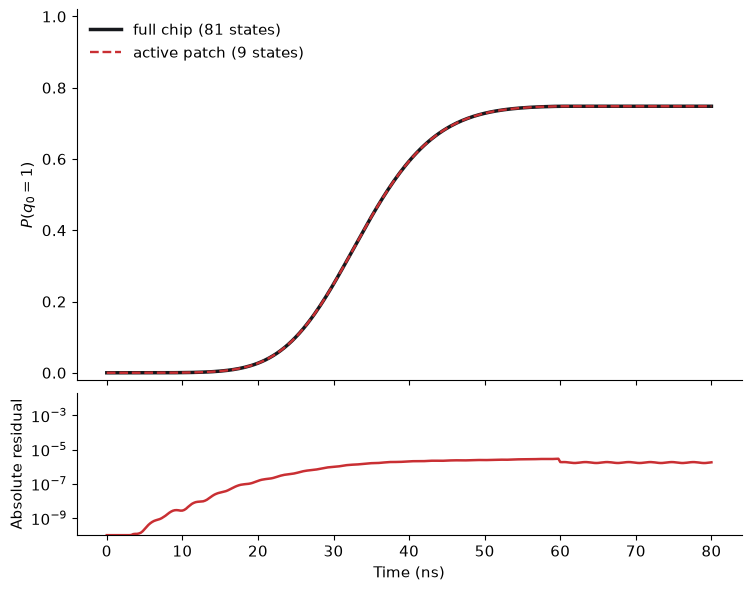

In [5]:
figure, (population_axis, residual_axis) = plt.subplots(
    2,
    1,
    figsize=(7.4, 5.8),
    height_ratios=(3.0, 1.15),
    sharex=True,
    layout="constrained",
)

population_axis.plot(times, full_population, color="#16181C", linewidth=2.5, label="full chip (81 states)")
population_axis.plot(
    times,
    reduced_population,
    color="#C92F33",
    linewidth=1.7,
    linestyle="--",
    label="active patch (9 states)",
)
population_axis.set_ylabel(r"$P(q_0=1)$")
population_axis.set_ylim(-0.02, 1.02)
population_axis.legend(frameon=False, loc="upper left")

display_residual = np.maximum(population_residual, 1.0e-10)
residual_axis.semilogy(times, display_residual, color="#C92F33", linewidth=1.8)
residual_axis.set(
    xlabel="Time (ns)",
    ylabel="Absolute residual",
    ylim=(1.0e-10, 2.0e-2),
)

figure_path = "../docs/images/reduce_and_replay.png"
figure.savefig(figure_path, dpi=180)
figure.savefig("../docs/images/reduce_and_replay.svg")
figure.savefig("../docs/images/reduce_and_replay.pdf")
plt.show()

</details>

```{figure} ../images/reduce_and_replay.svg
:alt: Driven-qubit population on the full chip and active patch, with their absolute difference below.

The full and reduced trajectories overlap; the lower panel resolves their
absolute difference. Values below 10⁻¹⁰ are floored for display only.
[PDF](../images/reduce_and_replay.pdf)
```

## Inspect the elimination report

Each entry in `patch.steps` is an `EliminationResult`. Its `describe()` report
includes frequency shifts, inherited loss, coupling ratios, and approximation
notes. The retained Hamiltonian corrections determine the reduced dynamics;
the source device parameters remain authored.

<details>
<summary>Show the built-in reports</summary>

In [6]:
for step in patch.steps:
    print(step.describe())

Elimination fold report (method='sw')
─────────────────────────────────────
q2: freq 5.7 → 5.69959 GHz   (Lamb shift -0.411 MHz)
validity: c23 g/Δ=0.034 ✓ (< 0.1) · min block gap 0.35 GHz
dropped: counter-rotating terms · ring-up transients · higher-order (>2) corrections
notes:
  - Retained the full second-order Hamiltonian correction and each transformed channel from the removed components; inherited decay remains collective and separate from intrinsic survivor noise.
Elimination fold report (method='sw')
─────────────────────────────────────
q1: freq 5.35 → 5.34959 GHz   (Lamb shift -0.412 MHz)
validity: c12 g/Δ=0.034 ✓ (< 0.1) · min block gap 0.35 GHz
dropped: counter-rotating terms · ring-up transients · higher-order (>2) corrections
notes:
  - Retained the full second-order Hamiltonian correction and each transformed channel from the removed components; inherited decay remains collective and separate from intrinsic survivor noise.


</details>

To remove a specific device directly, use `eliminate(chip, "q3", method="sw")`
and inspect the returned `.chip` and `.describe()`. `method="exact"` uses the
retained block of the diagonalized model instead of the second-order
Schrieffer–Wolff approximation. Eliminating a coupling retains both endpoints.

## Check this pulse comparison

A small coupling-to-detuning ratio is a diagnostic, not a guarantee of accurate
dynamics. Here we also check the full/reduced population difference against
`5(g/Δ)²`, using the retained–eliminated boundary. The factor of five allows
for multilevel and finite-pulse effects. Change `hops` to retain more neighbours
and repeat the comparison when changing the experiment.

<details>
<summary>Numerical checks and record</summary>

In [7]:
import json

full_dimension = int(np.prod(chip.dims))
reduced_dimension = int(np.prod(patch.chip.dims))
same_schedule = sequence.settings["entries"] == patch.sequence.settings["entries"]

validity_records = [
    record
    for eliminated_device in patch.validity.values()
    for record in eliminated_device.values()
]
max_g_over_delta = max(float(record["g_over_delta"]) for record in validity_records)
minimum_block_gap = min(float(record["min_block_gap"]) for record in validity_records)
all_folds_valid = all(bool(record["is_valid"]) for record in validity_records)

boundary_detuning = abs(float(chip.freq("q2")) - float(chip.freq("q1")))
boundary_ratio = coupling_strength / boundary_detuning
residual_tolerance = 5.0 * boundary_ratio**2
maximum_residual = float(np.max(population_residual))

if not all_folds_valid:
    raise RuntimeError("The active patch contains an invalid elimination step.")
if maximum_residual >= residual_tolerance:
    raise RuntimeError("The reduced dynamics exceed the validity-derived tolerance.")
if not same_schedule:
    raise RuntimeError("The reduced sequence does not preserve the scheduled entries.")
if tuple(device.label for device in chip.devices) != ("q0", "q1", "q2", "q3"):
    raise RuntimeError("active_patch() mutated the original chip.")

reduction_receipt = {
    "active_labels": list(patch.active_labels),
    "all_folds_valid": all_folds_valid,
    "eliminated_labels": list(patch.eliminated_labels),
    "figure": figure_path,
    "full_dimension": full_dimension,
    "maximum_population_residual": maximum_residual,
    "maximum_g_over_delta": max_g_over_delta,
    "minimum_block_gap_ghz": minimum_block_gap,
    "original_chip_unchanged": tuple(device.label for device in chip.devices) == ("q0", "q1", "q2", "q3"),
    "peak_full_population": float(np.max(full_population)),
    "reduced_dimension": reduced_dimension,
    "reduction_method": "sw",
    "residual_tolerance": residual_tolerance,
    "same_schedule": same_schedule,
}

print(f"RESULT reduction={json.dumps(reduction_receipt, sort_keys=True, separators=(',', ':'))}")

RESULT reduction={"active_labels":["q0","q1"],"all_folds_valid":true,"eliminated_labels":["q3","q2"],"figure":"../docs/images/reduce_and_replay.png","full_dimension":81,"maximum_g_over_delta":0.03432606492529982,"maximum_population_residual":2.920455710375691e-06,"minimum_block_gap_ghz":0.3495885714285709,"original_chip_unchanged":true,"peak_full_population":0.7479949561486069,"reduced_dimension":9,"reduction_method":"sw","residual_tolerance":0.0058774739885992825,"same_schedule":true}


</details>

## Other changes to the model

Use `with_params()` to change numerical parameters; the
[statics guide](statics-and-parameter-studies.md) demonstrates this during a sweep.
`chip.partition()` separates independent components exactly, while an active
patch approximates coupled spectators. Inspect `partition.notes` when shared
Hamiltonian terms, loss, or drive crosstalk keep components on a joint solve.